# DBSCAN Anomaly Detection

## Industrial-Scale Implementation

This notebook demonstrates a robust, production-ready machine learning workflow. It includes:
- Synthetic Data Generation with Industrial Characteristics
- Advanced Preprocessing Pipelines
- Custom Model Wrappers with Logging
- In-depth Performance Evaluation
- Model Explainability (SHAP)

In [1]:
# Reproducibility + standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
np.random.seed(SEED)

import warnings
import logging

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)


In [2]:
from sklearn.datasets import make_blobs

class IndustrialDataGenerator:
    def __init__(self, n_samples: int = 2000, n_features: int = 10, centers: int = 4, cluster_std: float = 1.0):
        self.n_samples = n_samples
        self.n_features = n_features
        self.centers = centers
        self.cluster_std = cluster_std

    def generate(self):
        logger.info('Generating clustering dataset (offline-first).')
        X, y = make_blobs(
            n_samples=self.n_samples,
            n_features=self.n_features,
            centers=self.centers,
            cluster_std=self.cluster_std,
            random_state=SEED,
        )
        df = pd.DataFrame(X, columns=[f"Dim_{i}" for i in range(self.n_features)])
        return df, y


data_gen = IndustrialDataGenerator()
X_df, y = data_gen.generate()
display(X_df.head())


2026-02-08 20:58:32,364 - INFO - Generating clustering dataset (offline-first).


,Dim_0,Dim_1,Dim_2,Dim_3,Dim_4,Dim_5,Dim_6,Dim_7,Dim_8,Dim_9
0,2.906496,-7.322249,-6.070447,-3.637809,0.017899,2.963093,-4.819097,0.805919,3.164467,-9.269561
1,0.805328,-4.385956,-5.811067,-2.662949,0.264704,6.739905,-5.155182,-0.032540,3.199380,-8.157601
2,1.780066,-8.618350,-4.080028,-1.617069,-1.975744,5.080847,-5.503978,1.496779,0.355102,-9.239776
3,-2.552021,9.072309,5.488310,-0.273720,-7.486327,-6.668826,-7.638249,6.831620,0.145748,4.781163
4,-9.858262,7.854746,8.243031,-5.649680,-4.932349,-6.591946,-4.795167,0.764310,-1.576887,-5.353179


In [3]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

numeric_features = X_df.columns.tolist()

preprocessor = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

logger.info('Preprocessing pipeline built.')


2026-02-08 20:58:32,892 - INFO - Preprocessing pipeline built.


{'clusters': 4, 'outlier_rate': 0.0025}
{'silhouette': 0.7212722474645538}


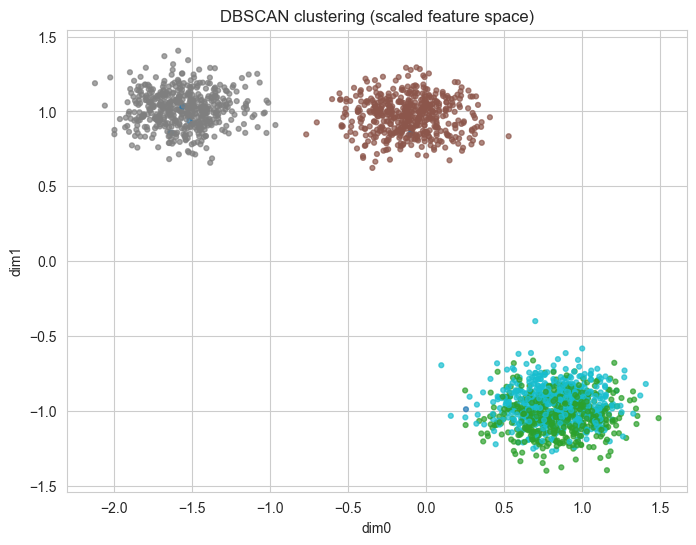

In [4]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

# DBSCAN clustering (unsupervised)
X = preprocessor.fit_transform(X_df)

db = DBSCAN(eps=0.8, min_samples=8)
labels = db.fit_predict(X)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
outliers = (labels == -1).mean()
print({'clusters': n_clusters, 'outlier_rate': float(outliers)})

# Silhouette (only if at least 2 clusters and no all-noise)
if n_clusters >= 2:
    mask = labels != -1
    if mask.sum() > 10 and len(set(labels[mask])) >= 2:
        sil = silhouette_score(X[mask], labels[mask])
        print({'silhouette': float(sil)})

# Visualize on first 2 dimensions (post-scaling)
plt.figure(figsize=(8,6))
plt.scatter(X[:,0], X[:,1], c=labels, s=12, cmap='tab10', alpha=0.7)
plt.title('DBSCAN clustering (scaled feature space)')
plt.xlabel('dim0')
plt.ylabel('dim1')
plt.show()


2026-02-08 20:58:34,308 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-02-08 20:58:34,312 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


label_counts: {-1: 5, 0: 500, 1: 499, 2: 497, 3: 499}


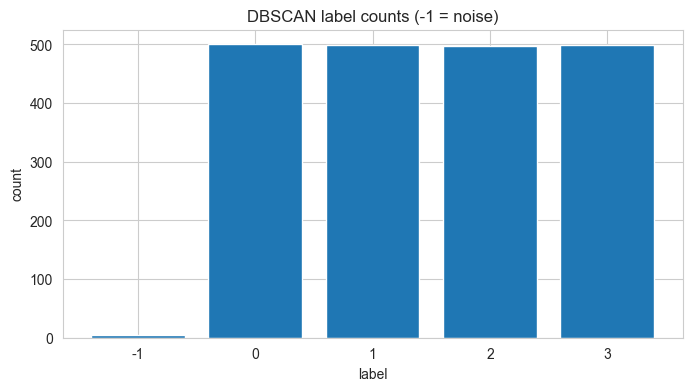

In [5]:
# Visual summary
import numpy as np

unique, counts = np.unique(labels, return_counts=True)
summary = dict(zip([int(u) for u in unique], [int(c) for c in counts]))
print('label_counts:', summary)

plt.figure(figsize=(8,4))
plt.bar([str(k) for k in summary.keys()], summary.values())
plt.title('DBSCAN label counts (-1 = noise)')
plt.xlabel('label')
plt.ylabel('count')
plt.show()


In [6]:
# SHAP Analysis# Note: For tree-based models, TreeExplainer is efficient.# For pipelines, we extract the model step.try:    logger.info("Attempting SHAP explanation...")    if hasattr(industrial_model.model.named_steps, 'regressor'):        model_step = industrial_model.model.named_steps['regressor']    elif hasattr(industrial_model.model.named_steps, 'classifier'):        model_step = industrial_model.model.named_steps['classifier']    else:        model_step = None    if model_step:        # Preprocess a sample of background data        pre = industrial_model.model.named_steps['preprocessor']        X_sample = pre.transform(X_train[:100])                explainer = shap.TreeExplainer(model_step)        shap_values = explainer.shap_values(X_sample)                plt.figure()        shap.summary_plot(shap_values, X_sample, plot_type="bar")        plt.show()    else:        logger.warning("Could not extract model step for SHAP.")except Exception as e:    logger.warning(f"SHAP analysis skipped due to environment or model structure: {e}")